# Project

MLF_GP1_CreditScore

### Part 1: EDA

In [ ]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# read data
df = pd.read_csv('../data/MLF_GP1_CreditScore.csv')

In [ ]:
def rating_grouping(row):

  high = ["Aa1", "Aa2", "Aa3" , "Aaa"]
  upper_mid = ["A1", "A2", "A3"]
  lower_mid = ["Baa1", "Baa2", "Baa3"]
  spec = ["Ba1", "Ba2", "Ba3"]
  high_spec = ["B1", "B2", "B3"]
  Caa = ["Caa1", "Caa2", "Caa3"]
  Ca = ["Ca1", "Ca2", "Ca3"]
  C = ["C1", "C2", "C3"]




  if (row.Rating in high):
    return 1 #High Grade
  elif (row.Rating in upper_mid):
    return 2 #High Medium
  elif (row.Rating in lower_mid):
    return 3 #Lower Medium"
  elif (row.Rating in spec):
    return 4 #Speculative"
  elif (row.Rating in high_spec):
    return 5 #Highly Speculative"
  elif (row.Rating in Caa):
    return 6 #Substantial Risk"
  elif (row.Rating in Ca):
    return 7 #Near Default"
  elif (row.Rating in C):
    return 8 #In Default"

In [ ]:
df["Rating_Group"] = df.apply(rating_grouping, axis=1)
df

,Sales/Revenues,Gross Margin,EBITDA,EBITDA Margin,Net Income Before Extras,Total Debt,Net Debt,LT Debt,ST Debt,Cash,...,Total Liquidity,Current Liquidity,Current Liabilities,EPS Before Extras,PE,ROA,ROE,InvGrd,Rating,Rating_Group
0,-0.005496,0.030763,0.018885,0.024515,0.146849,-0.029710,-0.019296,-0.042648,0.049875,-0.133716,...,0.392143,-0.184887,0.062781,0.148305,0.100409,0.163266,0.102521,1,A1,2
1,-0.005496,0.030763,0.088716,0.094733,0.146849,-0.029710,-0.019296,-0.042648,0.049875,-0.133716,...,0.392143,-0.184887,0.062781,0.148305,-0.089598,0.163266,0.102521,1,A1,2
2,-0.007045,0.023159,0.088716,0.096440,0.108590,0.039410,0.034268,0.009059,0.250371,0.101315,...,0.483257,-0.017877,0.121357,0.110656,-0.045142,0.105711,0.103378,1,A1,2
3,-0.009396,0.028400,0.088716,0.099046,0.146137,0.030071,0.036938,-0.016964,0.356994,-0.052606,...,0.996955,-0.122017,0.079051,0.151639,-0.008231,0.162421,0.132295,1,A1,2
4,-0.009009,0.027714,0.088716,0.098611,0.123500,0.024224,0.034445,-0.034132,0.461894,-0.090869,...,1.711426,-0.161561,0.084319,0.130435,0.015528,0.156427,0.225144,1,A1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,-0.099327,-0.010702,-0.127046,-0.030785,-4.349569,0.124830,0.146400,0.008407,0.364676,-0.028333,...,0.603271,-0.150779,0.144187,-4.408257,-1.339781,-4.271318,-5.168673,0,Caa1,6
1696,-0.116919,-0.009799,-0.155183,-0.043333,-2.937747,0.157873,0.066243,0.084104,0.309846,0.808505,...,0.007110,0.604043,0.127468,-2.977064,-1.695900,-2.868086,-3.429429,0,Caa1,6
1697,-0.099676,0.067595,-0.170022,-0.078134,-1.960264,0.023226,-0.201398,0.024856,0.020078,1.352542,...,-0.959809,1.227363,0.056198,-1.955285,-1.919739,-1.876336,-1.940995,0,Caa1,6
1698,-0.088853,0.007820,-0.122645,-0.037088,-2.066509,0.067495,-0.011377,0.289219,-0.171802,0.671224,...,-0.438389,0.865331,-0.104059,-2.059347,-1.462429,-2.027254,-2.059961,0,Caa1,6


In [ ]:
# Basic dataset information
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {len(df.columns)}")
print(f"Number of samples: {len(df)}")

Dataset shape: (1700, 29)
Number of features: 29
Number of samples: 1700


In [ ]:
# Check for missing values
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


In [ ]:
# Data types
print(df.dtypes)

Sales/Revenues              float64
Gross Margin                float64
EBITDA                      float64
EBITDA Margin               float64
Net Income Before Extras    float64
Total Debt                  float64
Net Debt                    float64
LT Debt                     float64
ST Debt                     float64
Cash                        float64
Free Cash Flow              float64
Total Debt/EBITDA           float64
Net Debt/EBITDA             float64
Total MV                    float64
Total Debt/MV               float64
Net Debt/MV                 float64
CFO/Debt                    float64
CFO                         float64
Interest Coverage           float64
Total Liquidity             float64
Current Liquidity           float64
Current Liabilities         float64
EPS Before Extras           float64
PE                          float64
ROA                         float64
ROE                         float64
InvGrd                        int64
Rating                      

In [ ]:
# Numerical Features Analysis
# Separate numerical features (excluding target variables)
numerical_features = [col for col in df.columns if col not in ['InvGrd', 'Rating', 'Rating_Group']]

print(f"Number of numerical features: {len(numerical_features)}")

print("\nBasic Statistics for Numerical Features:")
print(df[numerical_features].describe())

Number of numerical features: 26

Basic Statistics for Numerical Features:
       Sales/Revenues  Gross Margin       EBITDA  EBITDA Margin  \
count     1700.000000   1700.000000  1700.000000    1700.000000   
mean         0.050378      0.026007     0.068718       0.021074   
std          0.161910      0.273768     0.237365       0.189025   
min         -0.661715     -0.794722    -0.782254      -0.805153   
25%         -0.005693     -0.020028    -0.022640      -0.042771   
50%          0.034000      0.003403     0.049482       0.011134   
75%          0.083004      0.025595     0.124533       0.060566   
max          2.277229      3.202713     3.542425       4.141182   

       Net Income Before Extras   Total Debt     Net Debt      LT Debt  \
count               1700.000000  1700.000000  1700.000000  1700.000000   
mean                   0.123026     0.822405    -0.419810     1.255168   
std                   14.475689    13.317075    28.385702    16.224453   
min                 -289.

Investment Grade (InvGrd) distribution:
InvGrd
1    1287
0     413
Name: count, dtype: int64

Rating distribution:
Rating
Baa2    326
Baa3    232
Baa1    179
Aa3     174
A2      156
Ba2     125
A1      122
Ba3     108
B1       69
Aa2      65
B2       48
B3       37
A3       31
Ba1      17
Caa1      9
Aaa       2
Name: count, dtype: int64

Rating_group distribution:
Rating_Group
3    737
2    309
4    250
1    241
5    154
6      9
Name: count, dtype: int64


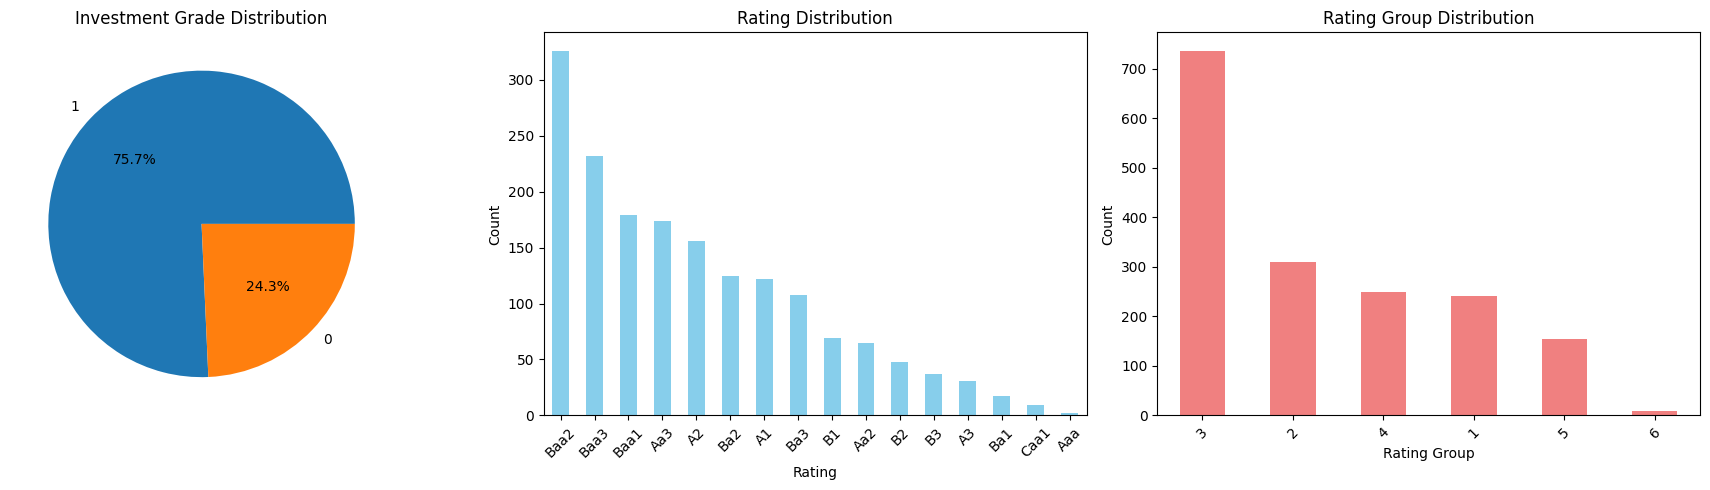

In [ ]:
# Target Variable Analysis

print("Investment Grade (InvGrd) distribution:")
print(df['InvGrd'].value_counts())

print("\nRating distribution:")
rating_counts = df['Rating'].value_counts()
print(rating_counts)

print("\nRating_group distribution:")
rating_group_counts = df['Rating_Group'].value_counts()
print(rating_group_counts)

# Visualize target variables
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Investment Grade distribution
ax1.pie(df['InvGrd'].value_counts(), labels=df['InvGrd'].value_counts().index, autopct='%1.1f%%')
ax1.set_title('Investment Grade Distribution')

# Rating distribution
rating_counts.plot(kind='bar', ax=ax2, color='skyblue')
ax2.set_title('Rating Distribution')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Rating_group distribution
rating_group_counts.plot(kind='bar', ax=ax3, color='lightcoral')
ax3.set_title('Rating Group Distribution')
ax3.set_xlabel('Rating Group')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Check for outliers using IQR
Q1 = df[numerical_features].quantile(0.25)
Q3 = df[numerical_features].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numerical_features] < (Q1 - 1.5 * IQR)) | (df[numerical_features] > (Q3 + 1.5 * IQR))).sum()
print(f"\nNumber of outliers per feature (using IQR):")
print(outliers.sort_values(ascending=False).head(10))


Number of outliers per feature (using IQR):
Net Income Before Extras    322
ROA                         317
EPS Before Extras           311
Net Debt                    311
ROE                         310
Net Debt/EBITDA             283
Total Liquidity             279
PE                          277
Free Cash Flow              270
Gross Margin                241
dtype: int64


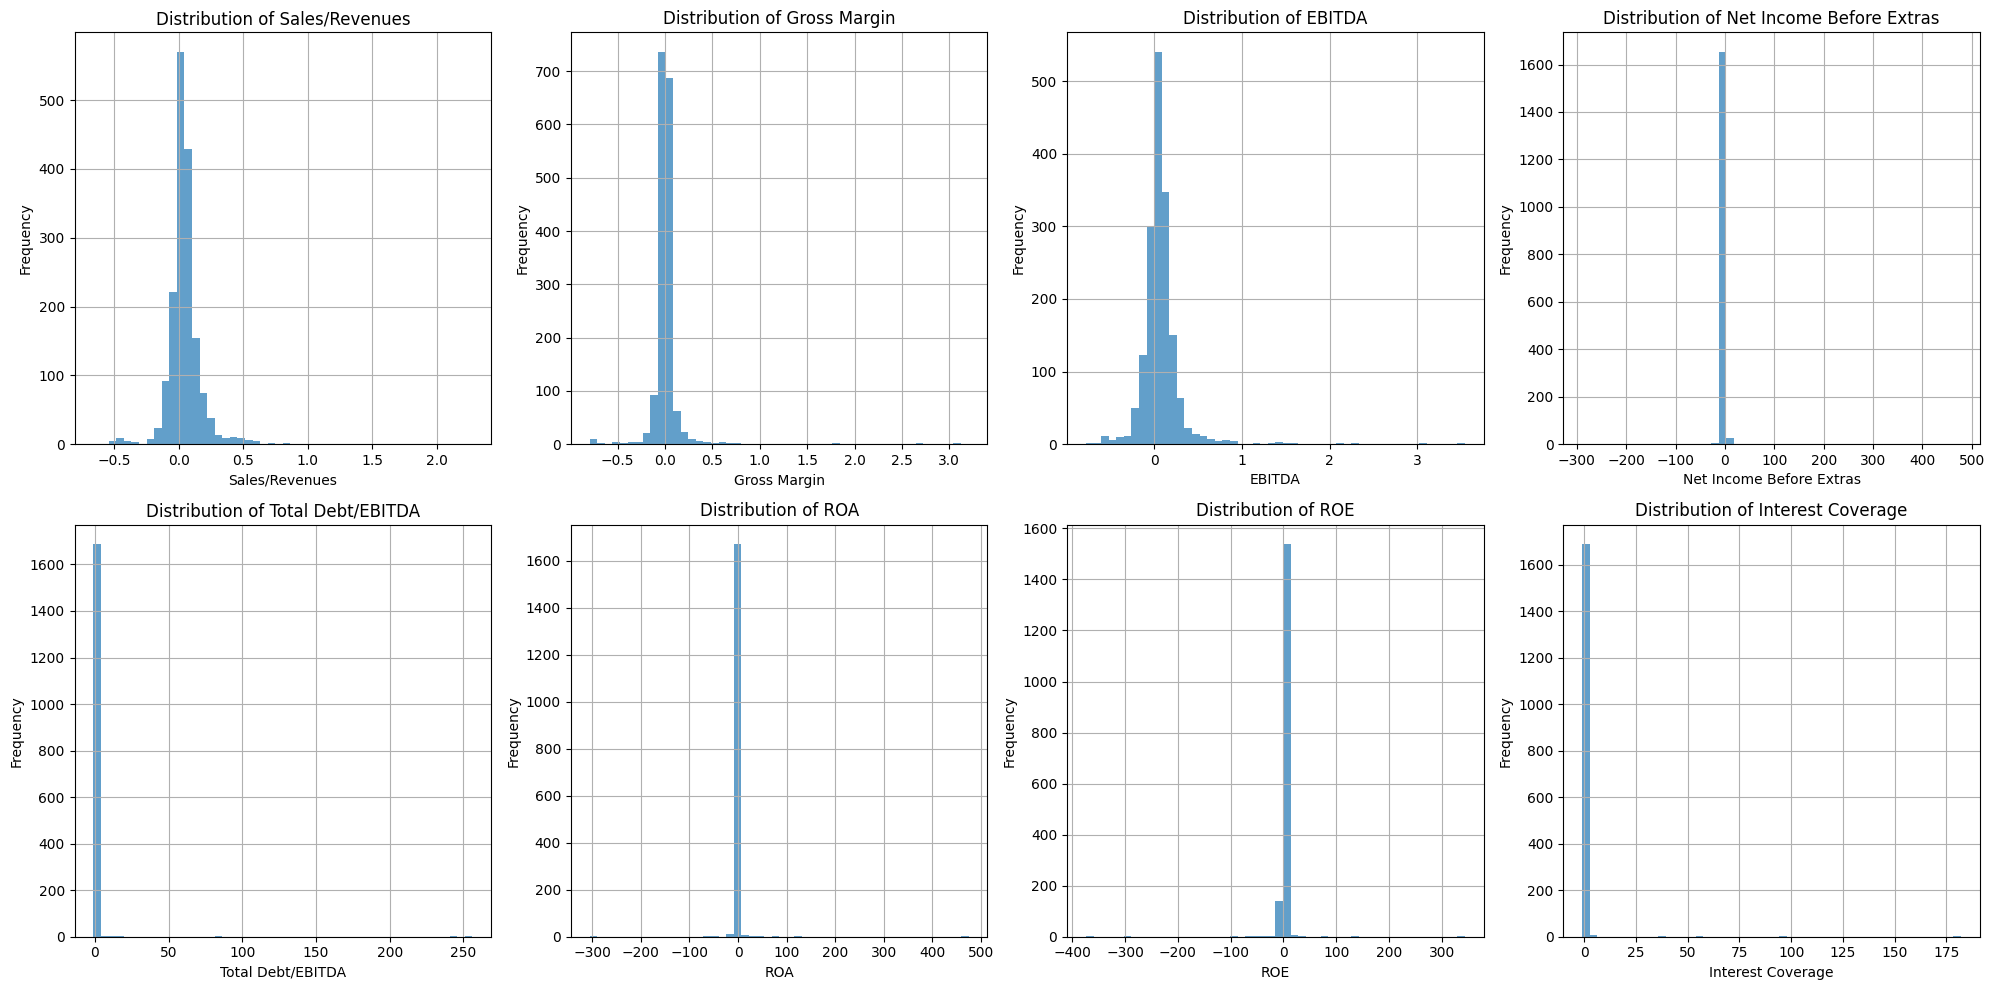

In [ ]:
# Distribution of Key Financial Ratios
key_ratios = ['Sales/Revenues', 'Gross Margin', 'EBITDA', 'Net Income Before Extras',
             'Total Debt/EBITDA', 'ROA', 'ROE', 'Interest Coverage']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, ratio in enumerate(key_ratios):
    if ratio in df.columns:
        df[ratio].hist(bins=50, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribution of {ratio}')
        axes[i].set_xlabel(ratio)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Highly correlated feature pairs (|corr| > 0.8):
Total Debt vs Total Debt/EBITDA: 0.999
Net Income Before Extras vs ROA: 0.997
CFO/Debt vs CFO: 0.991
Net Debt vs Net Debt/MV: 0.979
Cash vs Current Liquidity: 0.973
Total Debt vs Total Debt/MV: 0.964
Total Debt/EBITDA vs Total Debt/MV: 0.961
Net Debt vs Net Debt/EBITDA: 0.907
Net Debt/EBITDA vs Net Debt/MV: 0.848
Total Debt vs LT Debt: 0.834


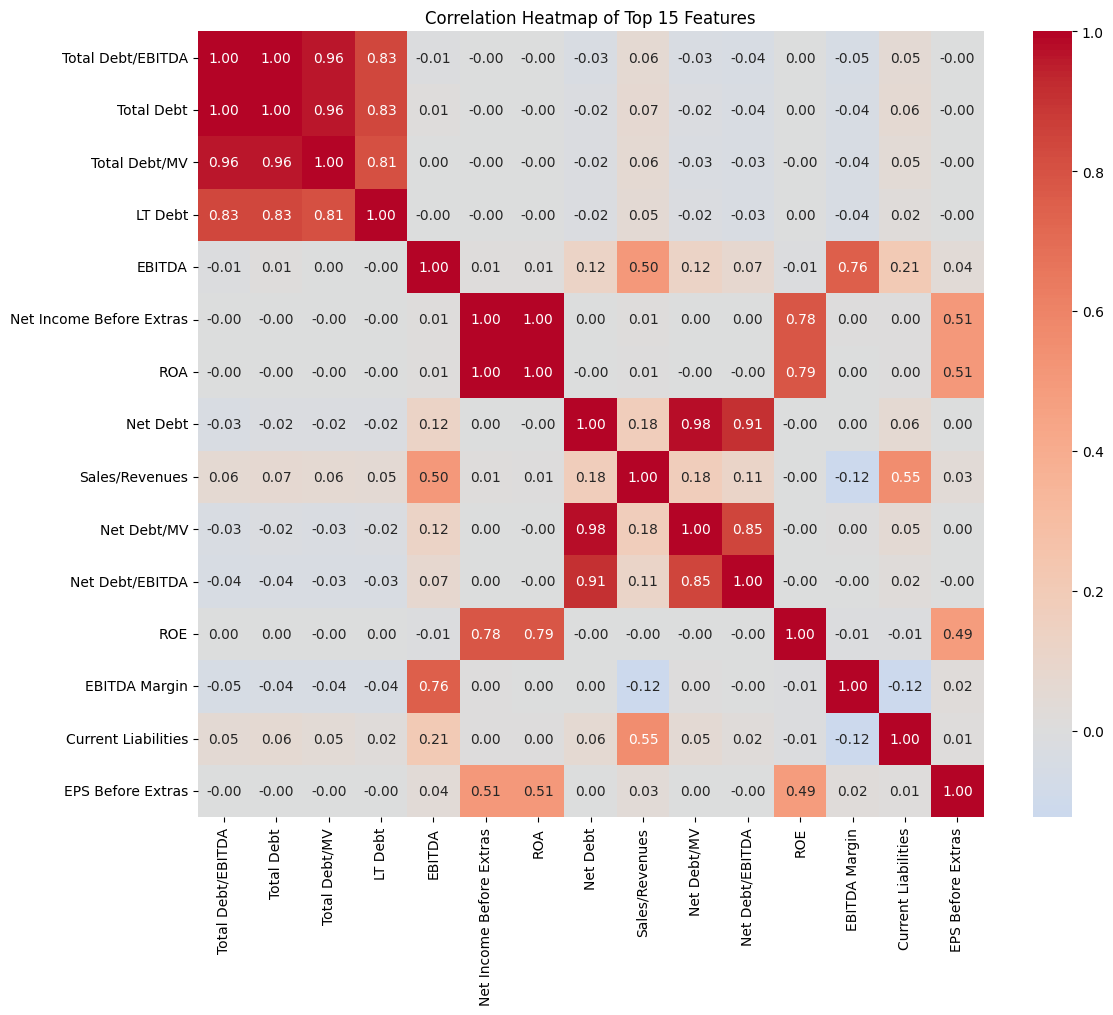

In [ ]:
# Correlation Analysis
# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()

# Find highly correlated features (absolute correlation > 0.8)
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print("Highly correlated feature pairs (|corr| > 0.8):")
for pair in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"{pair[0]} vs {pair[1]}: {pair[2]:.3f}")

# Plot correlation heatmap for top correlated features
plt.figure(figsize=(12, 10))
top_features = correlation_matrix.abs().sum().sort_values(ascending=False).index[:15]
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Correlation Heatmap of Top 15 Features')
plt.tight_layout()
plt.show()

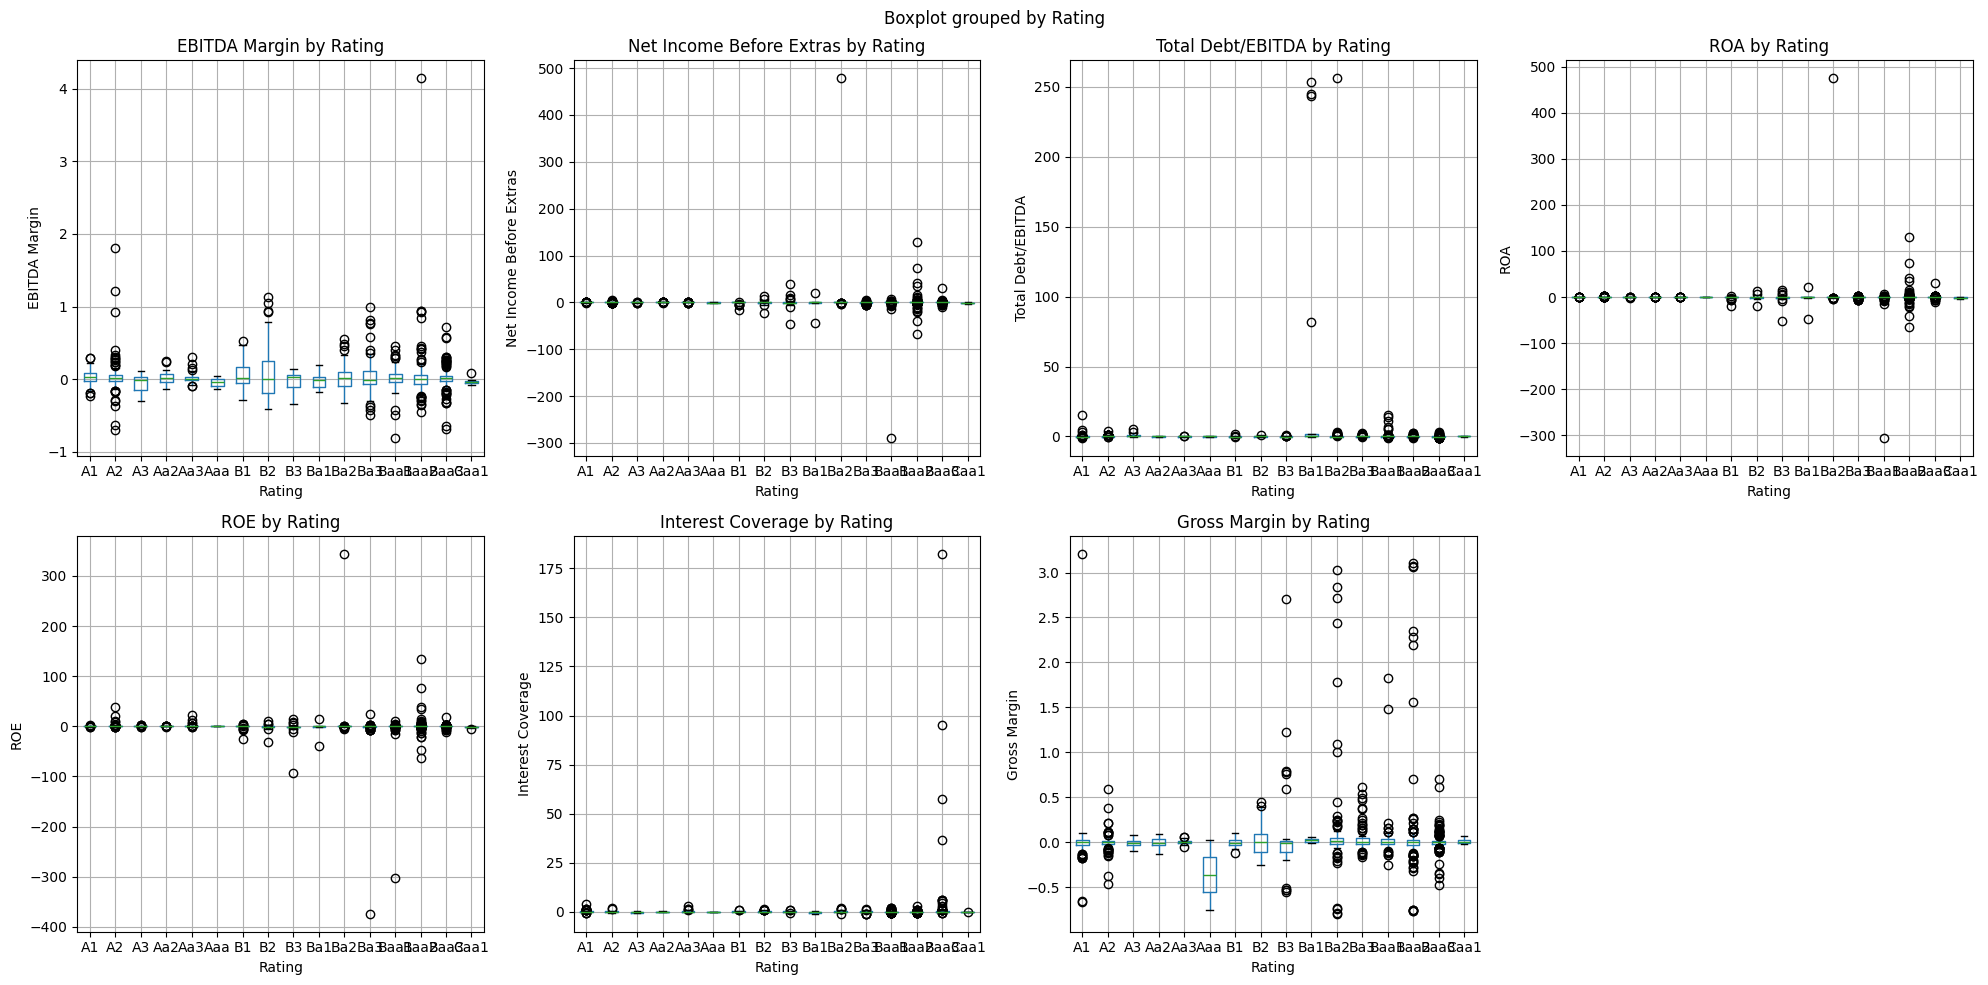

In [ ]:
# Feature Distribution by Rating
# Select a subset of important features for visualization
important_features = ['EBITDA Margin', 'Net Income Before Extras', 'Total Debt/EBITDA',
                     'ROA', 'ROE', 'Interest Coverage', 'Gross Margin']

# Create boxplots for important features by rating
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(important_features):
    if i < len(axes) and feature in df.columns:
        df.boxplot(column=feature, by='Rating', ax=axes[i])
        axes[i].set_title(f'{feature} by Rating')
        axes[i].set_ylabel(feature)

# Remove empty subplots
for i in range(len(important_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

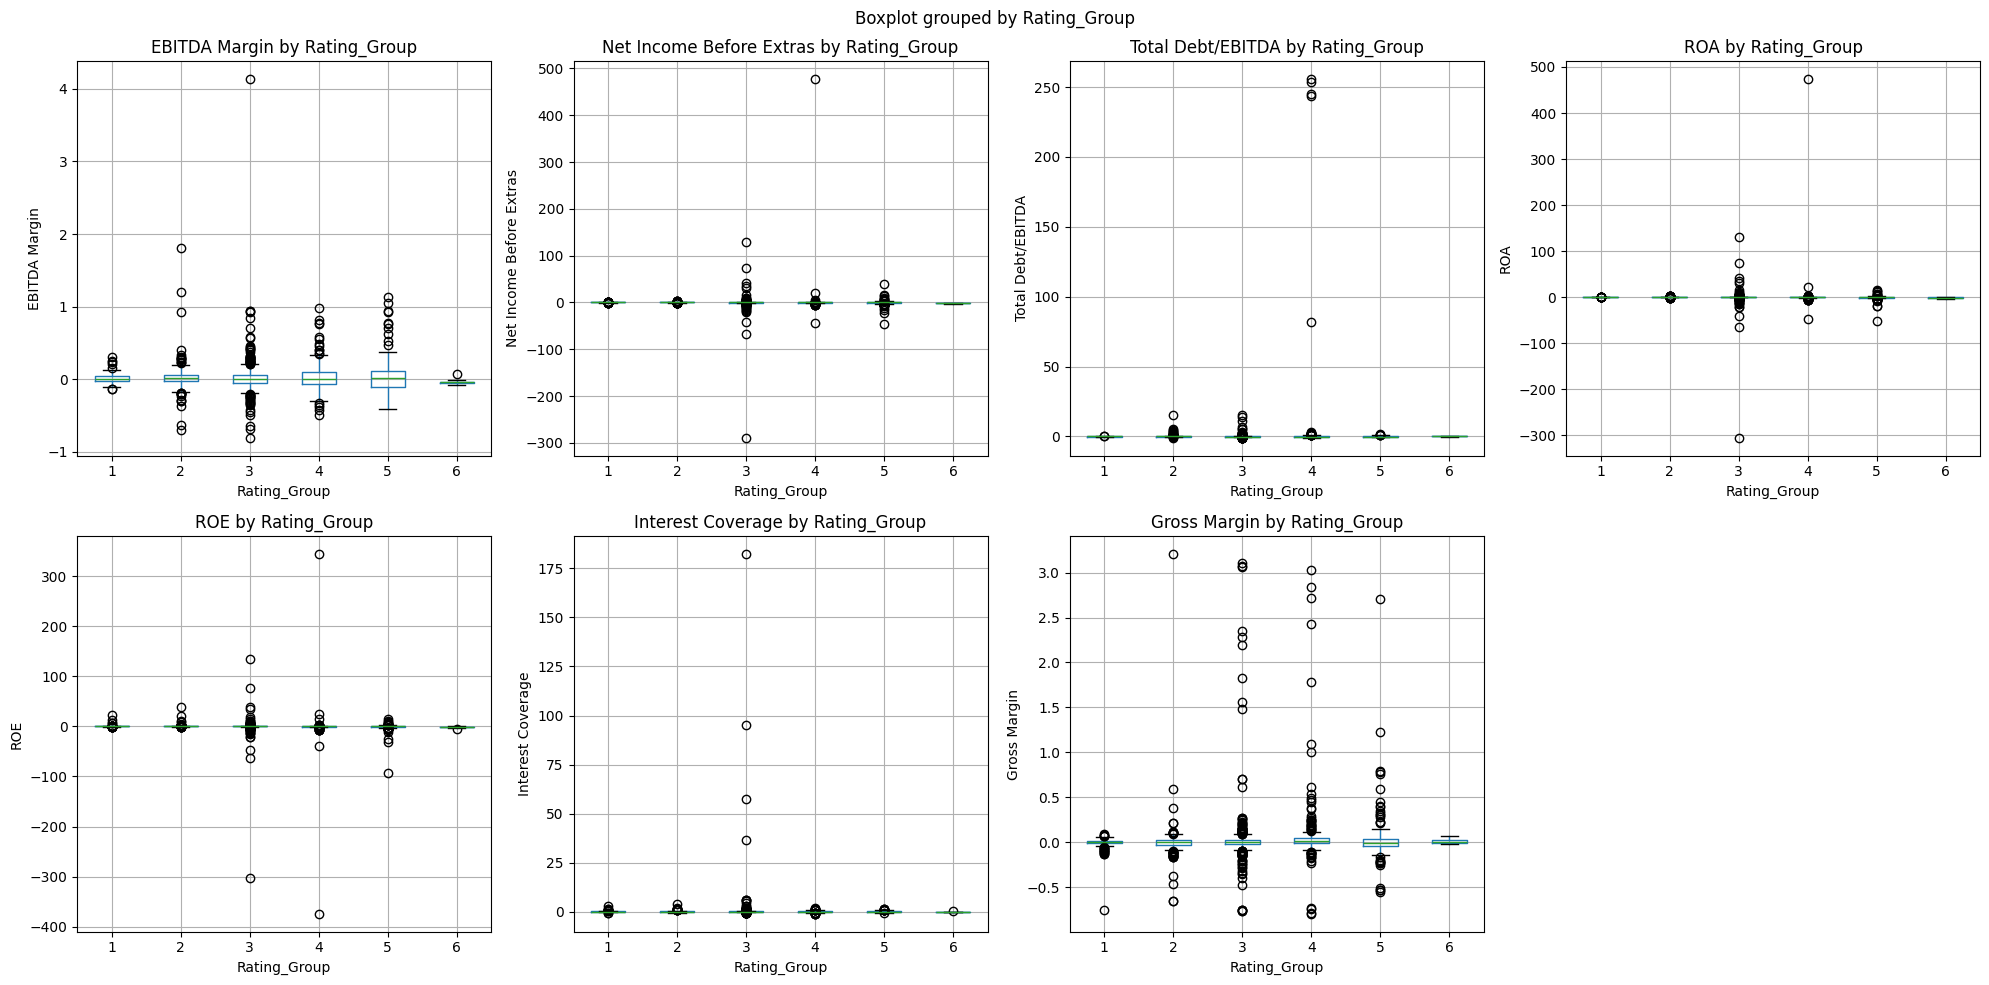

In [ ]:
# Feature Distribution by Rating
# Select a subset of important features for visualization
important_features = ['EBITDA Margin', 'Net Income Before Extras', 'Total Debt/EBITDA',
                     'ROA', 'ROE', 'Interest Coverage', 'Gross Margin']

# Create boxplots for important features by rating
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(important_features):
    if i < len(axes) and feature in df.columns:
        df.boxplot(column=feature, by='Rating_Group', ax=axes[i])
        axes[i].set_title(f'{feature} by Rating_Group')
        axes[i].set_ylabel(feature)

# Remove empty subplots
for i in range(len(important_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

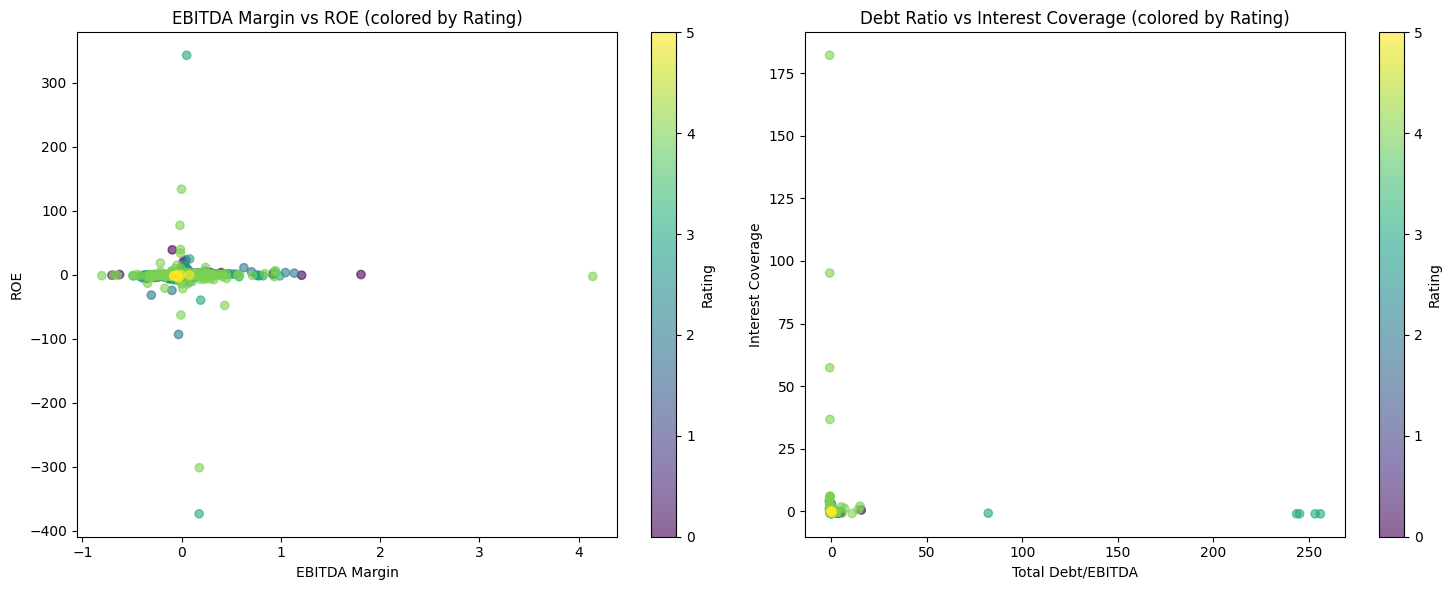

In [ ]:
# Multivariate Analysis
# Scatter plot of key financial metrics colored by rating
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# EBITDA Margin vs ROE
scatter1 = ax1.scatter(df['EBITDA Margin'], df['ROE'], c=pd.factorize(df['Rating_Group'])[0],
                      alpha=0.6, cmap='viridis')
ax1.set_xlabel('EBITDA Margin')
ax1.set_ylabel('ROE')
ax1.set_title('EBITDA Margin vs ROE (colored by Rating)')
plt.colorbar(scatter1, ax=ax1, label='Rating')

# Total Debt/EBITDA vs Interest Coverage
scatter2 = ax2.scatter(df['Total Debt/EBITDA'], df['Interest Coverage'],
                      c=pd.factorize(df['Rating_Group'])[0], alpha=0.6, cmap='viridis')
ax2.set_xlabel('Total Debt/EBITDA')
ax2.set_ylabel('Interest Coverage')
ax2.set_title('Debt Ratio vs Interest Coverage (colored by Rating)')
plt.colorbar(scatter2, ax=ax2, label='Rating')

plt.tight_layout()
plt.show()

In [ ]:
# Statistical Tests and Group Comparisons
print("STATISTICAL COMPARISON BY RATING")

# Compare means by rating group
rating_groups = df.groupby('Rating_Group')

for feature in important_features:
    if feature in df.columns:
        print(f"\n{feature}:")
        print(rating_groups[feature].mean().sort_values())

# ANOVA test for significant differences (simplified)
from scipy import stats

print("\nSTATISTICAL SIGNIFICANCE TEST")
for feature in important_features[:3]:  # Test first 3 features
    if feature in df.columns:
        groups = [group[feature].values for name, group in rating_groups]
        f_stat, p_value = stats.f_oneway(*groups)
        print(f"{feature}: F-statistic = {f_stat:.3f}, p-value = {p_value:.3f}")

STATISTICAL COMPARISON BY RATING

EBITDA Margin:
Rating_Group
6   -0.033430
1    0.014614
3    0.017586
4    0.021676
2    0.023682
5    0.044853
Name: EBITDA Margin, dtype: float64

Net Income Before Extras:
Rating_Group
6   -1.662266
5   -0.430029
3   -0.263990
1    0.063458
2    0.139289
4    1.706222
Name: Net Income Before Extras, dtype: float64

Total Debt/EBITDA:
Rating_Group
1    0.026442
5    0.035274
3    0.094383
6    0.170097
2    0.207179
4    4.384484
Name: Total Debt/EBITDA, dtype: float64

ROA:
Rating_Group
6   -1.621803
5   -0.740734
3   -0.335475
1    0.005474
2    0.081420
4    1.529623
Name: ROA, dtype: float64

ROE:
Rating_Group
6   -1.750048
5   -1.209382
4   -0.451312
3   -0.343853
1    0.264856
2    0.435231
Name: ROE, dtype: float64

Interest Coverage:
Rating_Group
6   -0.148860
2    0.025320
4    0.065170
5    0.074293
1    0.108484
3    0.607290
Name: Interest Coverage, dtype: float64

Gross Margin:
Rating_Group
1   -0.000640
2    0.001754
6    0.015972
3    

In [ ]:
# Data Quality Assessment
print("DATA QUALITY ASSESSMENT")

# Check for constant or near-constant features
constant_features = []
for col in numerical_features:
    if df[col].nunique() <= 1:
        constant_features.append(col)

print(f"Constant features: {constant_features}")

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

# Check data ranges and potential errors
print("\nData Ranges Check:")
for feature in ['EBITDA', 'Net Income Before Extras', 'ROA', 'ROE']:
    if feature in df.columns:
        print(f"{feature}: min={df[feature].min():.3f}, max={df[feature].max():.3f}")

DATA QUALITY ASSESSMENT
Constant features: []
Duplicate rows: 0

Data Ranges Check:
EBITDA: min=-0.782, max=3.542
Net Income Before Extras: min=-289.000, max=478.280
ROA: min=-305.462, max=474.847
ROE: min=-373.837, max=343.145


Part 2: Preprocessing, feature extraction, feature selection

In [ ]:
X = df.drop(['InvGrd', 'Rating', 'Rating_Group'], axis=1)
X = X.drop(["Total Debt", "Total Debt/MV", "Net Debt", "Net Debt/MV", "Net Income Before Extras"], axis=1)


In [ ]:
y = df['Rating_Group']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:

# BInary Classifier Data Splits
X_b = df.drop(["InvGrd", "Rating", "Rating_Group", "Total Debt", "Total Debt/MV", "Net Debt", "Net Debt/MV", "Net Income Before Extras"], axis=1)
y_b = df["InvGrd"]

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(X_b, y_b, test_size=0.2, stratify=y, random_state=42)

Pipelines

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

In [ ]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced_subsample")
rf_pipe = Pipeline([
    ("scaler", scaler),
    ("rf", rf)
])

In [ ]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42, class_weight="balanced"),
    random_state=42
)
ada_pipe = Pipeline([
    ("scaler", scaler),
    ("ada", ada)
])

In [ ]:
logit_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("lr", LogisticRegression(
        solver="saga",
        max_iter=100000,
        n_jobs=-1,
        random_state=42
    ))
])

**Binary**

In [ ]:
# Binary Classifiers
tree_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("tree", DecisionTreeClassifier(random_state=42))
])

logreg_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("logreg", LogisticRegression(solver="saga",
        max_iter=100000,
        n_jobs=-1,
        random_state=42))
])

Part 3: Model fitting and evaluation



In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

Part 4: Hyperparameter tuning



In [ ]:
from sklearn.model_selection import GridSearchCV

RandomForrest Hyperparameter Tunning

In [ ]:
param_grid = {
    "rf__n_estimators":      [300, 600, 900, 1200],
    "rf__max_depth":         [None, 8, 12, 16],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf":  [1, 2, 4],
    "rf__max_features":      ["sqrt", "log2", 0.5],
    "rf__criterion":       ["gini"],
}

In [ ]:
from sklearn.model_selection import GridSearchCV
search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

In [ ]:
print("Best params:", search.best_params_)
print("Best CV accuracy:", search.best_score_)
best_rf = search.best_estimator_

Best params: {'rf__criterion': 'gini', 'rf__max_depth': None, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 1200}
Best CV accuracy: 0.6724264705882353

Runtime: 25m 2.5s

In [ ]:
param_grid = {
    "rf__n_estimators":      [1100, 1150, 1200, 1250],
    "rf__max_depth":         [None],
    "rf__min_samples_split": [2, 3],
    "rf__min_samples_leaf":  [1, 2, 3],
    "rf__max_features":      ["sqrt", "log2", 0.5],
    "rf__criterion":       ["gini"],
}

In [ ]:
from sklearn.model_selection import GridSearchCV
search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

In [ ]:
print("Best params:", search.best_params_)
print("Best CV accuracy:", search.best_score_)
best_rf = search.best_estimator_

Best params: {'rf__criterion': 'gini', 'rf__max_depth': None, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 1250}
Best CV accuracy: 0.6738970588235293

Runtime: 7m 34.5s

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


rf_model = best_rf.named_steps["rf"] if hasattr(best_rf, "named_steps") else best_rf


try:
    feature_names = X_train.columns
except AttributeError:
    feature_names = [f"Feature {i}" for i in range(rf_model.n_features_in_)]


importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)


print(importances.head(15))


plt.figure(figsize=(10,6))
plt.barh(importances["Feature"][:15][::-1], importances["Importance"][:15][::-1])
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

              Feature  Importance
12                CFO    0.079896
0      Sales/Revenues    0.072929
17  EPS Before Extras    0.061346
19                ROA    0.052089
7      Free Cash Flow    0.051714
1        Gross Margin    0.051570
11           CFO/Debt    0.050477
18                 PE    0.049241
20                ROE    0.049199
4             LT Debt    0.047152
10           Total MV    0.045514
13  Interest Coverage    0.044932
9     Net Debt/EBITDA    0.043381
3       EBITDA Margin    0.040467
2              EBITDA    0.040226

ADABoost Hyperparameter Tunning

In [ ]:
param_grid = {
    "ada__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "ada__n_estimators": [300, 500, 700, 900, 1100],
    "ada__estimator__max_depth": [1, 2, 3],
    "ada__estimator__min_samples_leaf": [1, 2, 3, 4, 5],
    "ada__estimator__class_weight": [None]
}

In [ ]:
ada_grid = GridSearchCV(
    estimator=ada_pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [ ]:

ada_grid.fit(X_train, y_train)
print("Best params:", ada_grid.best_params_)
print("Best CV accuracy:", ada_grid.best_score_)
best_ada = ada_grid.best_estimator_

Best params: {'ada__estimator__class_weight': None, 'ada__estimator__max_depth': 3, 'ada__estimator__min_samples_leaf': 5, 'ada__learning_rate': 0.3, 'ada__n_estimators': 1100}
Best CV accuracy: 0.5540441176470589

Runtime: 23m 59.6s

In [ ]:
param_grid = {
    "ada__learning_rate": [0.25, 0.275, 0.3],
    "ada__n_estimators": [1050, 1100, 1200, 1250],
    "ada__estimator__max_depth": [2, 3],
    "ada__estimator__min_samples_leaf": [4, 5, 6],
    "ada__estimator__class_weight": [None]
}

In [ ]:

ada_grid = GridSearchCV(
    estimator=ada_pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [ ]:
ada_grid.fit(X_train, y_train)
print("Best params:", ada_grid.best_params_)
print("Best CV accuracy:", ada_grid.best_score_)
best_ada = ada_grid.best_estimator_

Best params: {'ada__estimator__class_weight': None, 'ada__estimator__max_depth': 3, 'ada__estimator__min_samples_leaf': 5, 'ada__learning_rate': 0.3, 'ada__n_estimators': 1250}
Best CV accuracy: 0.55625

Runtime: 10m 35.3s

Logistic Regression Tunning

In [ ]:
logit_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("lr", LogisticRegression(
        solver="saga",
        max_iter=100000,
        n_jobs=-1,
        random_state=42
    ))
])


In [ ]:
from sklearn.preprocessing import StandardScaler
param_grid_lr = {
    "scaler": [RobustScaler(), StandardScaler()],

    "lr__penalty": ["elasticnet"],

    "lr__C": np.logspace(-4, 3, 10),

    "lr__l1_ratio": [0.0, 0.25, 0.5, 0.75],

    "lr__class_weight": [None, "balanced"],


    "lr__tol": [1e-4, 1e-5],
}

In [ ]:
lr_search = GridSearchCV(
    estimator=logit_pipe,
    param_grid=param_grid_lr,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_search.fit(X_train, y_train)

In [ ]:
print("LR best params:", lr_search.best_params_)
print("LR best CV accuracy:", lr_search.best_score_)

best_lr = lr_search.best_estimator_

LR best params: {'lr__C': np.float64(27.825594022071257), 'lr__class_weight': None, 'lr__l1_ratio': 0.25, 'lr__penalty': 'elasticnet', 'lr__tol': 1e-05, 'scaler': RobustScaler()}
LR best CV accuracy: 0.4448529411764707

Runtime: 46m 52.1s

**Binary**

Decision Tree Hyperparameter Tuning

In [ ]:
tree_param_grid = {
    "tree__max_depth": [1, 3, 5, 8, 10, 14, 20],
    "tree__min_samples_leaf": [1, 5, 10],
    "tree__min_samples_split": [2, 10, 20]
}

In [ ]:
tree_grid = GridSearchCV(
    estimator = tree_pipe,
    param_grid = tree_param_grid,
    scoring="accuracy",
    cv = cv,
    n_jobs = -1,
    verbose=1
)

In [ ]:
tree_grid.fit(X_b_train, y_b_train)
print("Best DT params:", tree_grid.best_params_)
print("Best DT CV Accuracy:", tree_grid.best_score_)
best_tree = tree_grid.best_estimator_

Fitting 10 folds for each of 63 candidates, totalling 630 fits
Best DT params: {'tree__max_depth': 14, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Best DT CV Accuracy: 0.7860294117647058

Runtime: 1.2s

Logistic Regression Hyperparameter Tuning

In [ ]:
logreg_param_grid = [
    {
        "logreg__penalty": ["l1"],
        "logreg__C": np.logspace(-4, 3, 10),
    },
    {
        "logreg__penalty": ["l2"],
        "logreg__C": np.logspace(-4, 3, 10),
    },
    {
        "logreg__penalty": ["elasticnet"],
        "logreg__C": np.logspace(-4, 3, 10),
        "logreg__l1_ratio": [0.25, 0.5, 0.75],
    },
]

In [ ]:
logreg_grid = GridSearchCV(
    estimator = logreg_pipe,
    param_grid = logreg_param_grid,
    scoring = "accuracy",
    cv = cv,
    n_jobs = -1,
    verbose = 1
)

In [ ]:
logreg_grid.fit(X_b_train, y_b_train)
print("Best LR params:", logreg_grid.best_params_)
print("Best LR CV Accuracy:", logreg_grid.best_score_)
best_logreg = logreg_grid.best_estimator_

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best LR params: {'logreg__C': np.float64(0.0001), 'logreg__penalty': 'l1'}
Best LR CV Accuracy: 0.7573529411764707

Runtime: 55.7s

Part 5: Ensembling

In [ ]:
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(
    estimators=[("rf", best_rf), ("ada", best_ada)],
    voting="soft", weights=[1,1]
)

In [ ]:
weight_grid = {"weights": [(1,1),(2,1),(1,2),(3,1),(1,3),(4,1),(1,4)]}

In [ ]:
vote_search = GridSearchCV(
    estimator=ensemble,
    param_grid=weight_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

vote_search.fit(X_train, y_train)

In [ ]:
best_voter = vote_search.best_estimator_
print("Best weights:", vote_search.best_params_["weights"])
vote_search.best_score_

Best weights: (1, 1)
np.float64(0.6746323529411764)

In [ ]:
weight_grid2 = {
    "weights": [
        # --- Balanced weights ---
        (1, 1, 1),
        (2, 1, 1),
        (1, 2, 1),
        (1, 1, 2),
        # --- RF-dominant ---
        (3, 1, 1),
        (4, 1, 1),
        # --- Ada-dominant ---
        (1, 3, 1),
        (1, 4, 1),
        # --- LR-dominant ---
        (1, 1, 3),
        (1, 1, 4),
        # --- Combined bias towards two models ---
        (2, 2, 1),
        (2, 1, 2),
        (1, 2, 2),
        # --- Edge-case extremes ---
        (5, 1, 1),
        (1, 5, 1),
        (1, 1, 5)
    ]
}

In [ ]:
from sklearn.ensemble import VotingClassifier
ensemble2 = VotingClassifier(
    estimators=[("rf", best_rf), ("ada", best_ada), ("lr", best_lr)],
    voting="soft", weights=[1,1]
)

In [ ]:
vote_search2 = GridSearchCV(
    estimator=ensemble2,
    param_grid=weight_grid2,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

vote_search2.fit(X_train, y_train)

In [ ]:
best_voter2 = vote_search2.best_estimator_
print("Best weights:", vote_search2.best_params_["weights"])
vote_search2.best_score_

Best weights: (5, 1, 1)
np.float64(0.6511029411764706)

Runtime: 16m 40.9s

In [ ]:
from sklearn.metrics import accuracy_score
y_pred_test_rf = best_rf.predict(X_test)
y_pred_test_voter = best_voter.predict(X_test)
y_pred_test_ada = best_ada.predict(X_test)
y_pred_test_lr = best_lr.predict(X_test)
y_pred_test_voter2 = best_voter2.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_test_rf)
print(f"RF Test Accuracy: {acc_rf:.4f}\n")

acc_voter = accuracy_score(y_test, y_pred_test_voter)
print(f"Voter Test Accuracy: {acc_voter:.4f}\n")

acc_ada = accuracy_score(y_test, y_pred_test_ada)
print(f"ADA Test Accuracy: {acc_ada:.4f}\n")

acc_lr = accuracy_score(y_test, y_pred_test_lr)
print(f"LR Test Accuracy: {acc_lr:.4f}\n")

acc_voter2 = accuracy_score(y_test, y_pred_test_voter2)
print(f"Voter2 Test Accuracy: {acc_voter2:.4f}\n")

RF Test Accuracy: 0.7294

Voter Test Accuracy: 0.7265

ADA Test Accuracy: 0.5735

LR Test Accuracy: 0.4765

Voter2 Test Accuracy: 0.7324

**Binary**

In [ ]:
ensemble_binary = VotingClassifier(
    estimators=[("dTree", best_tree), ("log_reg", best_logreg)],
    voting="soft", weights=[1,1]
)

In [ ]:
weight_grid = {"weights": [(1,1),(2,1),(1,2),(3,1),(1,3),(4,1),(1,4)]}

In [ ]:
vote_search_binary = GridSearchCV(
    estimator=ensemble_binary,
    param_grid=weight_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

vote_search_binary.fit(X_b_train, y_b_train)

In [ ]:
best_voter_binary = vote_search_binary.best_estimator_
print("Best weights:", vote_search_binary.best_params_["weights"])
vote_search_binary.best_score_

Best weights: (1, 1)
np.float64(0.7860294117647058)

Runtime: 0.5s

In [ ]:
y_pred_test_tree = best_tree.predict(X_b_test)
y_pred_test_logreg = best_logreg.predict(X_b_test)
y_pred_test_voter_binary = best_voter_binary.predict(X_b_test)

acc_tree = accuracy_score(y_b_test, y_pred_test_tree)
print(f"dTree Test Accuracy: {acc_tree:.4f}\n")

acc_logreg = accuracy_score(y_b_test, y_pred_test_logreg)
print(f"LogReg Test Accuracy: {acc_rf:.4f}\n")

acc_voter_bin = accuracy_score(y_b_test, y_pred_test_voter_binary)
print(f"Binary Voter Test Accuracy: {acc_voter_bin:.4f}\n")

dTree Test Accuracy: 0.8176

LogReg Test Accuracy: 0.7294

Binary Voter Test Accuracy: 0.8176